# Category-Level Privacy Patterns

Analysis for category-level z-score comparisons of privacy metrics.

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

metrics_results = Path("../data/mhealth_apps_metrics.csv")
if not metrics_results.exists():
    raise FileNotFoundError(
        "Could not find `mhealth_apps_metrics.csv` in the notebook folder or at ../data/."
    )

REGION_MAP = {
    "us": "North America", "ca": "North America", "gl":"North America",
    "mx": "Latin America", "br": "Latin America", "ar": "Latin America", 
    "cl": "Latin America",
    "de": "Europe", "fr": "Europe", "gb": "Europe", 
    "pl": "Europe",
    "tr": "Middle East", "il": "Middle East", "sa": "Middle East", 
    "ae": "Middle East",
    "in": "Asia", "jp": "Asia", "sg": "Asia", 
    "kr": "Asia",
    "za": "Africa", "mz": "Africa", "ng": "Africa", 
    "ke": "Africa",
    "au": "Oceania", "nz": "Oceania", 
    "pg": "Oceania"
}

COUNTRY_LABEL_MAP = {
    "us": "United States", "ca": "Canada", "gl":"Greenland",
    "mx": "Mexico", "br": "Brazil", "ar": "Argentina",
    "cl": "Chile",
    "de": "Germany", "fr": "France", "gb": "Great Britain",
    "pl": "Poland",
    "tr": "Turkey", "il": "Israel", "sa": "Saudi Arabia",
    "ae": "United Arab Emirates",
    "in": "India", "jp": "Japan", "sg": "Singapore",
    "kr": "South Korea",
    "za": "South Africa", "mz": "Mozambique", "ng": "Nigeria",
    "ke": "Kenya",
    "au": "Australia", "nz": "New Zealand",
    "pg": "Papua New Guinea"
}

REGION_ORDER = [
    "North America", "Latin America", "Europe",
    "Middle East", "Asia", "Africa", "Oceania"
]

region_palette = plt.cm.tab10(np.linspace(0, 1, len(REGION_ORDER)))
REGION_COLORS = {region: region_palette[i] for i, region in enumerate(REGION_ORDER)}
category_palette = plt.cm.tab20(np.linspace(0, 1, 20))


In [7]:
import pandas as pd

df = pd.read_csv(metrics_results, low_memory=False)
print("Raw shape:", df.shape)

required_metrics = ["ADII", "DGI", "PCLR", "AS"]
missing_required = [c for c in required_metrics if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required metric columns: {missing_required}")

analysis_df = df.copy()

print("Analysis shape:", analysis_df.shape)
print("Unique apps:", analysis_df["app_id"].nunique())

display_cols = [
    "app_id", "country", "country_label", "region", "category",
    "ADII", "DGI", "PCLR", "AS",
    "observed_count", "disclosed_count", "missing_count", "misleading_count"
]
display_cols = [c for c in display_cols if c in analysis_df.columns]

Raw shape: (23392, 134)
Analysis shape: (23392, 134)
Unique apps: 931


In [8]:

summary = pd.DataFrame({
    "non_null": analysis_df[["ADII", "DGI", "PCLR", "AS"]].notna().sum(),
    "mean": analysis_df[["ADII", "DGI", "PCLR", "AS"]].mean(),
    "median": analysis_df[["ADII", "DGI", "PCLR", "AS"]].median(),
    "std": analysis_df[["ADII", "DGI", "PCLR", "AS"]].std(),
    "min": analysis_df[["ADII", "DGI", "PCLR", "AS"]].min(),
    "max": analysis_df[["ADII", "DGI", "PCLR", "AS"]].max(),
}).round(4)
summary


,non_null,mean,median,std,min,max
ADII,23392,189.0859,100.0000,323.8028,7.0000,12935.0000
DGI,23392,0.2559,0.0000,0.3968,0.0000,1.0000
PCLR,11967,0.3063,0.2000,0.3386,0.0000,1.0000
AS,23383,0.3787,0.3761,0.0924,0.1064,0.7473


In [9]:

country_level = analysis_df.copy()

metric_agg = {
    "ADII": "mean",
    "DGI": "mean",
    "PCLR": "mean",
    "AS": "mean",
}

meta_agg = {
    "country_label": "nunique",
    "region": lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan,
    "category": lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan,
    "num_permissions": "mean",
    "num_dangerous_permissions": "mean",
    "num_trackers": "mean",
    "downloads_int": "mean",
    "average_score": "mean",
}

agg_dict = {}
for k, v in {**metric_agg, **meta_agg}.items():
    if k in analysis_df.columns:
        agg_dict[k] = v

app_level = analysis_df.groupby("app_id", as_index=False).agg(agg_dict)
app_level = app_level.rename(columns={"country_label": "country_count"})
app_level_all = app_level.copy()

if "PCLR" not in app_level_all.columns:
    if "app_country_PCLR" in analysis_df.columns:
        pclr_fallback = (
            analysis_df.groupby("app_id", as_index=False)["app_country_PCLR"]
            .mean()
            .rename(columns={"app_country_PCLR": "PCLR"})
        )
        app_level_all = app_level_all.merge(pclr_fallback, on="app_id", how="left")
    elif {"app_country_pre_sensitive_instances", "app_country_total_sensitive_instances"}.issubset(analysis_df.columns):
        pclr_fallback = (
            analysis_df.groupby("app_id", as_index=False)[
                ["app_country_pre_sensitive_instances", "app_country_total_sensitive_instances"]
            ]
            .mean()
        )
        denom = pclr_fallback["app_country_total_sensitive_instances"].replace(0, np.nan)
        pclr_fallback["PCLR"] = pclr_fallback["app_country_pre_sensitive_instances"] / denom
        app_level_all = app_level_all.merge(pclr_fallback[["app_id", "PCLR"]], on="app_id", how="left")

print("Country-level rows:", len(country_level))
print("App-level rows:", len(app_level_all))
print("App-level metric columns:", [c for c in ["ADII", "DGI", "PCLR", "AS"] if c in app_level_all.columns])
app_level = app_level_all.copy()



Country-level rows: 23392
App-level rows: 931
App-level metric columns: ['ADII', 'DGI', 'PCLR', 'AS']



## Figure — Category heatmap of normalized metric means

A heatmap is useful for comparing relative patterns across categories and metrics at the same time.

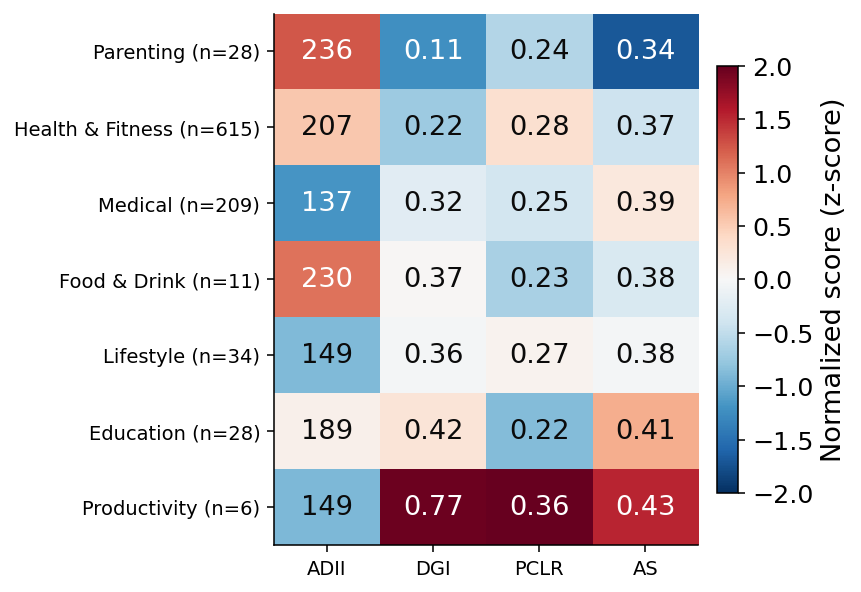

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

output_dir = Path("../figures")
output_dir.mkdir(parents=True, exist_ok=True)

TEXT_PRIMARY = "#0b0b0b"

cat_means = app_level_all.groupby("category")[["ADII", "DGI", "PCLR", "AS"]].mean()

cat_order = ["Parenting", "Health & Fitness", "Medical", "Food & Drink", "Lifestyle",
             "Education", "Productivity"]
cat_order = [c for c in cat_order if c in cat_means.index]
cat_means = cat_means.reindex(cat_order)

category_counts = (
    app_level_all.groupby("category")["app_id"].nunique().reindex(cat_order)
)

z = (cat_means - cat_means.mean()) / cat_means.std()
z = z.clip(-2, 2)

fig, ax = plt.subplots(figsize=(6.2, 4.4))
im = ax.imshow(z.values, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(4))
ax.set_xticklabels(["ADII", "DGI", "PCLR", "AS"])
ax.set_yticks(range(len(cat_order)))
ax.set_yticklabels([f"{cat} (n={category_counts.loc[cat]})" for cat in cat_order])
ax.grid(False)
for i in range(z.shape[0]):
    for j in range(z.shape[1]):
        raw = cat_means.values[i, j]
        txt = f"{raw:.2f}" if j != 0 else f"{raw:.0f}"
        color = "white" if abs(z.values[i, j]) > 1 else TEXT_PRIMARY
        ax.text(j, i, txt, ha="center", va="center", fontsize=14, color=color)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Normalized score (z-score)", fontsize=14)
cbar.ax.tick_params(labelsize=13)
fig.tight_layout()
fig.savefig(output_dir / "category_privacy_heatmap.pdf", format="pdf", bbox_inches="tight")
plt.show()
